# Tutorial 6 — DINOv2 Feature Distillation with YOLOv26 for Brain-Tumor Segmentation

**Course:** CSE445 — Computer Vision  
**Instructor:** Dr Mohammad Rifat Ahmmad Rashid  

**Dataset:** Brain Tumor Image Dataset — Semantic Segmentation  
**Kaggle source:** `pkdarabi/brain-tumor-image-dataset-semantic-segmentation`


**Pipeline:** unlabeled MRI images → frozen DINOv2 teacher → dense DINOv2 patch features → YOLOv26 multi-scale student features → feature projection and distillation → transfer the distilled YOLOv26 network → supervised tumor segmentation → held-out evaluation.

This notebook uses **DINOv2 ViT-S/14** as a frozen teacher. The teacher is not fine-tuned. The YOLOv26 segmentation network learns to imitate DINOv2's dense patch representation using the same MRI images without consulting tumor labels during Stage A.

> Two epochs are intentionally configured for a fast Kaggle/classroom demonstration. They are not enough for a research-quality comparison.

> **Kaggle Internet note:** the official DINOv2 weights are loaded from Meta's PyTorch Hub repository. Enable Internet for the notebook, or attach a local DINOv2 repository and checkpoint and fill in the optional paths in `CFG`.

## How DINOv2 + YOLOv26 works

For an augmented MRI image $x$, the frozen DINOv2 teacher produces a grid of patch-token features:

$$
T = f_{\text{DINOv2}}(x),
\qquad
T \in \mathbb{R}^{B\times D\times H_t\times W_t}.
$$

The YOLOv26 student produces multi-scale convolutional feature maps:

$$
\{F_1,F_2,F_3\}=f_{\text{YOLOv26}}(x).
$$

A trainable projection module maps every YOLO feature level to the DINOv2 embedding dimension, resizes the maps to the teacher patch grid, and fuses them:

$$
S = \sum_{k=1}^{3}\alpha_k\,P_k(F_k),
\qquad
\sum_k\alpha_k=1.
$$

The notebook optimizes a weighted combination of four objectives:

$$
\mathcal{L}_{\text{distill}}
=
\lambda_1\mathcal{L}_{\text{dense-cos}}
+
\lambda_2\mathcal{L}_{\text{dense-Huber}}
+
\lambda_3\mathcal{L}_{\text{global-cos}}
+
\lambda_4\mathcal{L}_{\text{affinity}}.
$$

- **Dense cosine loss** aligns each student location with the corresponding DINOv2 patch token.
- **Dense Huber loss** aligns standardized feature values while being less sensitive to outliers than MSE.
- **Global cosine loss** aligns pooled image-level representations.
- **Affinity loss** aligns pairwise relationships among spatial tokens.

After distillation, the projection module and frozen teacher are discarded. Only the distilled YOLOv26 segmentation network is transferred to supervised fine-tuning.

```text
MRI image ────────────────────────────────┐
                                         │
                     ┌───────────────────▼───────────────────┐
                     │ Frozen DINOv2 ViT-S/14 teacher        │
                     │ dense patch tokens: B × 384 × 16 × 16│
                     └───────────────────┬───────────────────┘
                                         │ teacher target
                                         ▼
                              multi-term distillation loss
                                         ▲
                                         │ projected student map
                     ┌───────────────────┴───────────────────┐
                     │ YOLOv26 multi-scale student backbone  │
                     │ P3 + P4 + P5 → project → resize → fuse│
                     └───────────────────────────────────────┘
```

## Learning objectives

Students will learn to:

1. distinguish self-distillation from contrastive and reconstruction-based SSL;
2. extract dense DINOv2 patch tokens with a frozen Vision Transformer;
3. expose multi-scale features inside an Ultralytics YOLOv26 segmentation graph;
4. project convolutional features into a transformer embedding space;
5. combine dense, global, and relational distillation losses;
6. transfer the distilled YOLOv26 weights into supervised segmentation;
7. evaluate representation transfer using segmentation metrics and qualitative predictions.

In [1]:
# Cell 1 — Install dependencies
!pip install -q -U ultralytics lxml scikit-learn timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 91.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
# Cell 2 — Imports, configuration, reproducibility, and device
import copy
import json
import math
import os
import random
import shutil
import time
import warnings
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.manifold import TSNE

from ultralytics import YOLO
import ultralytics

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class CFG:
    seed: int = 42
    num_workers: int = 2
    prefetch_factor: int = 2
    persistent_workers: bool = True

    # Exact dataset path requested by the user. The resolver also supports
    # Kaggle's shorter mount convention.
    data_root: str = "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation"
    working_root: str = "/kaggle/working/cse445_dinov2_yolov26"
    prepared_dataset_name: str = "brain_tumor_yolo_seg"

    # YOLOv26 segmentation architecture.
    yolo_model: str = "yolo26n-seg.yaml"

    # Frozen DINOv2 teacher. ViT-S/14 is memory-efficient for Kaggle GPUs.
    dinov2_model: str = "dinov2_vits14"

    # Optional offline paths. Leave empty when Kaggle Internet is enabled.
    # Example:
    # dinov2_local_repo = "/kaggle/input/dinov2-repository/dinov2"
    # dinov2_local_weights = "/kaggle/input/dinov2-weights/dinov2_vits14_pretrain.pth"
    dinov2_local_repo: str = ""
    dinov2_local_weights: str = ""

    # Stage A — DINOv2 → YOLOv26 feature distillation.
    distillation_image_size: int = 224  # divisible by DINOv2 patch size 14
    distillation_batch_size: int = 8
    distillation_epochs: int = 5
    distillation_learning_rate: float = 2e-4
    distillation_weight_decay: float = 1e-4
    gradient_accumulation_steps: int = 1
    dense_cosine_weight: float = 1.0
    dense_huber_weight: float = 0.25
    global_cosine_weight: float = 0.50
    affinity_weight: float = 0.10
    use_torch_compile: bool = False

    # Stage B — supervised segmentation fine-tuning.
    segmentation_image_size: int = 640
    segmentation_batch_size: int = 8
    segmentation_epochs: int = 10
    segmentation_patience: int = 5

    # Optional classroom/debug settings.
    debug_subset: Optional[int] = None
    tsne_max_samples: int = 300


cfg = CFG()

if cfg.distillation_image_size % 14 != 0:
    raise ValueError("distillation_image_size must be divisible by 14 for DINOv2 ViT/14.")
if cfg.gradient_accumulation_steps < 1:
    raise ValueError("gradient_accumulation_steps must be at least 1.")

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = device.type == "cuda"

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

# Resolve both common Kaggle mount conventions.
requested_root = Path(cfg.data_root)
alternative_roots = [
    requested_root,
    Path("/kaggle/input/brain-tumor-image-dataset-semantic-segmentation"),
]

DATA_ROOT = next((path for path in alternative_roots if path.exists()), requested_root)
if not DATA_ROOT.exists() and Path("/kaggle/input").exists():
    discovered = sorted(
        path for path in Path("/kaggle/input").iterdir()
        if path.is_dir() and "brain-tumor" in path.name.lower()
    )
    if discovered:
        DATA_ROOT = discovered[0]

WORKING_ROOT = Path(cfg.working_root)
PREPARED_ROOT = WORKING_ROOT / cfg.prepared_dataset_name
DISTILL_OUTPUT_DIR = WORKING_ROOT / "dinov2_distillation_outputs"
SEGMENTATION_PROJECT_DIR = WORKING_ROOT / "segmentation_runs"

for directory in [WORKING_ROOT, DISTILL_OUTPUT_DIR, SEGMENTATION_PROJECT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    SCALER = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
else:
    SCALER = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def amp_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def unwrap_model(model):
    return model._orig_mod if hasattr(model, "_orig_mod") else model


print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)
print("Resolved dataset root:", DATA_ROOT)
print("DINOv2 distillation epochs:", cfg.distillation_epochs)
print("Segmentation epochs:", cfg.segmentation_epochs)
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.95
PyTorch: 2.10.0+cu128
Device: cuda
Resolved dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
DINOv2 distillation epochs: 5
Segmentation epochs: 10


,value
seed,42
num_workers,2
prefetch_factor,2
persistent_workers,True
data_root,/kaggle/input/datasets/pkdarabi/brain-tumor-im...
working_root,/kaggle/working/cse445_dinov2_yolov26
prepared_dataset_name,brain_tumor_yolo_seg
yolo_model,yolo26n-seg.yaml
dinov2_model,dinov2_vits14
dinov2_local_repo,


## 1. Prepare the Kaggle brain-tumor segmentation dataset

The Kaggle dataset is commonly exported in a Roboflow-style COCO layout:

```text
dataset-root/
├── train/
│   ├── _annotations.coco.json
│   └── image files
├── valid/
│   ├── _annotations.coco.json
│   └── image files
└── test/
    ├── _annotations.coco.json
    └── image files
```

Each COCO annotation contains one or more tumor polygons. Ultralytics segmentation labels use one row per polygon:

$$
c,\quad x_1/W,\quad y_1/H,\quad x_2/W,\quad y_2/H,\ldots,x_n/W,\quad y_n/H.
$$

The conversion cells recursively locate COCO annotation files, preserve the supplied train/validation/test split, normalize polygon coordinates, remove invalid polygons, and create an Ultralytics-compatible `data.yaml`. The original Kaggle input is never modified.

In [3]:
# Cell 3 — Discover and parse COCO segmentation annotations
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root was not found: {DATA_ROOT}\n"
        "Attach the Kaggle dataset or update CFG.data_root."
    )

annotation_files = sorted(DATA_ROOT.rglob("*annotations*.json"))
if not annotation_files:
    annotation_files = sorted(DATA_ROOT.rglob("*.json"))

if not annotation_files:
    raise FileNotFoundError(
        f"No COCO JSON annotation file was found under {DATA_ROOT}."
    )


def infer_split_name(annotation_path):
    text = " ".join(part.lower() for part in annotation_path.parts)
    if "train" in text:
        return "train"
    if "valid" in text or "val" in text:
        return "val"
    if "test" in text:
        return "test"
    return None


def locate_coco_image(annotation_path, file_name):
    candidates = [
        annotation_path.parent / file_name,
        annotation_path.parent / Path(file_name).name,
        DATA_ROOT / file_name,
        DATA_ROOT / Path(file_name).name,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    matches = list(DATA_ROOT.rglob(Path(file_name).name))
    return matches[0] if matches else None


def polygon_area(flat_polygon):
    points = np.asarray(flat_polygon, dtype=np.float64).reshape(-1, 2)
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(
        np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
    )


all_records = []
category_id_to_name = {}
failed_items = []

for annotation_path in annotation_files:
    split_name = infer_split_name(annotation_path)
    if split_name is None:
        continue

    try:
        coco = json.loads(annotation_path.read_text(encoding="utf-8"))
    except Exception as error:
        failed_items.append((str(annotation_path), str(error)))
        continue

    local_categories = {
        int(category["id"]): str(category["name"])
        for category in coco.get("categories", [])
    }
    category_id_to_name.update(local_categories)

    annotations_by_image = {}
    for annotation in coco.get("annotations", []):
        annotations_by_image.setdefault(int(annotation["image_id"]), []).append(annotation)

    for image_info in coco.get("images", []):
        image_id = int(image_info["id"])
        image_path = locate_coco_image(annotation_path, image_info["file_name"])
        if image_path is None:
            failed_items.append((image_info["file_name"], "image not found"))
            continue

        width = int(image_info.get("width", 0))
        height = int(image_info.get("height", 0))
        if width <= 0 or height <= 0:
            with Image.open(image_path) as image:
                width, height = image.size

        polygon_instances = []
        for annotation in annotations_by_image.get(image_id, []):
            category_id = int(annotation["category_id"])
            segmentation = annotation.get("segmentation", [])

            # Polygon-style COCO annotations are expected. Compressed RLE
            # masks require pycocotools and contour extraction.
            if not isinstance(segmentation, list):
                continue

            for polygon in segmentation:
                if not isinstance(polygon, list) or len(polygon) < 6:
                    continue
                if len(polygon) % 2 != 0:
                    polygon = polygon[:-1]
                if len(polygon) < 6 or polygon_area(polygon) <= 1.0:
                    continue

                polygon_instances.append({
                    "category_id": category_id,
                    "category_name": local_categories.get(category_id, str(category_id)),
                    "polygon": polygon,
                })

        all_records.append({
            "split": split_name,
            "image_path": str(image_path),
            "width": width,
            "height": height,
            "polygons": polygon_instances,
            "number_of_masks": len(polygon_instances),
        })


dataset_frame = pd.DataFrame(all_records)
if dataset_frame.empty:
    raise RuntimeError("No valid COCO image records were found.")

if cfg.debug_subset is not None:
    sampled_parts = []
    for split_name, split_frame in dataset_frame.groupby("split"):
        sampled_parts.append(
            split_frame.sample(
                min(cfg.debug_subset, len(split_frame)),
                random_state=cfg.seed,
            )
        )
    dataset_frame = pd.concat(sampled_parts, ignore_index=True)

category_names = sorted(set(category_id_to_name.values()))
if not category_names:
    raise RuntimeError("No category names were found in the COCO annotations.")

category_name_to_yolo_id = {
    category_name: index
    for index, category_name in enumerate(category_names)
}
class_names = category_names

print(f"Annotation files: {len(annotation_files)}")
print(f"Valid images: {len(dataset_frame):,}")
print(f"Skipped items: {len(failed_items):,}")
print("Split counts:")
display(dataset_frame["split"].value_counts().rename_axis("split").to_frame("images"))
print("Classes:", class_names)
display(dataset_frame[["split", "image_path", "width", "height", "number_of_masks"]].head())

Annotation files: 3
Valid images: 2,146
Skipped items: 0
Split counts:


,images
split,
train,1502
val,429
test,215


Classes: ['0', '1', 'Tumor']


,split,image_path,width,height,number_of_masks
0,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
1,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
2,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
3,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
4,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1


In [4]:
# Cell 4 — Export Ultralytics polygon-segmentation labels
def polygon_to_yolo_line(instance, width, height):
    class_id = category_name_to_yolo_id[instance["category_name"]]
    coordinates = np.asarray(instance["polygon"], dtype=np.float64).reshape(-1, 2)

    coordinates[:, 0] = np.clip(coordinates[:, 0] / width, 0.0, 1.0)
    coordinates[:, 1] = np.clip(coordinates[:, 1] / height, 0.0, 1.0)

    flattened = coordinates.reshape(-1)
    if len(flattened) < 6:
        return None

    return f"{class_id} " + " ".join(f"{value:.6f}" for value in flattened)


split_frames = {
    split_name: split_frame.reset_index(drop=True)
    for split_name, split_frame in dataset_frame.groupby("split")
}

required_splits = {"train", "val", "test"}
missing_splits = required_splits - set(split_frames)
if missing_splits:
    raise RuntimeError(
        f"Missing expected dataset splits: {sorted(missing_splits)}. "
        "Check the Kaggle directory structure."
    )

if PREPARED_ROOT.exists():
    shutil.rmtree(PREPARED_ROOT)

for split_name in required_splits:
    (PREPARED_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (PREPARED_ROOT / "labels" / split_name).mkdir(parents=True, exist_ok=True)

manifest_rows = []

for split_name, frame in split_frames.items():
    for row_index, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc=f"Exporting {split_name}",
        leave=False,
    ):
        source_image = Path(row["image_path"])
        destination_name = f"{row_index:06d}_{source_image.name}"
        destination_image = PREPARED_ROOT / "images" / split_name / destination_name
        destination_label = (
            PREPARED_ROOT
            / "labels"
            / split_name
            / f"{Path(destination_name).stem}.txt"
        )

        shutil.copy2(source_image, destination_image)

        label_lines = []
        for instance in row["polygons"]:
            line = polygon_to_yolo_line(
                instance,
                int(row["width"]),
                int(row["height"]),
            )
            if line is not None:
                label_lines.append(line)

        destination_label.write_text(
            "\n".join(label_lines),
            encoding="utf-8",
        )

        manifest_rows.append({
            "split": split_name,
            "image_path": str(destination_image),
            "label_path": str(destination_label),
            "number_of_masks": len(label_lines),
        })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(PREPARED_ROOT / "manifest.csv", index=False)

data_yaml = PREPARED_ROOT / "data.yaml"
yaml_lines = [
    f"path: {PREPARED_ROOT}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "names:",
]
yaml_lines.extend(
    f"  {class_id}: {class_name}"
    for class_name, class_id in category_name_to_yolo_id.items()
)
data_yaml.write_text("\n".join(yaml_lines), encoding="utf-8")

summary = manifest.groupby("split").agg(
    images=("image_path", "count"),
    masks=("number_of_masks", "sum"),
    mean_masks_per_image=("number_of_masks", "mean"),
)
display(summary.round(3))
print(data_yaml.read_text())

Exporting test:   0%|          | 0/215 [00:00<?, ?it/s]

Exporting train:   0%|          | 0/1502 [00:00<?, ?it/s]

Exporting val:   0%|          | 0/429 [00:00<?, ?it/s]

,images,masks,mean_masks_per_image
split,,,
test,215,215,1.0
train,1502,1502,1.0
val,429,429,1.0


path: /kaggle/working/cse445_dinov2_yolov26/brain_tumor_yolo_seg
train: images/train
val: images/val
test: images/test
names:
  0: 0
  1: 1
  2: Tumor


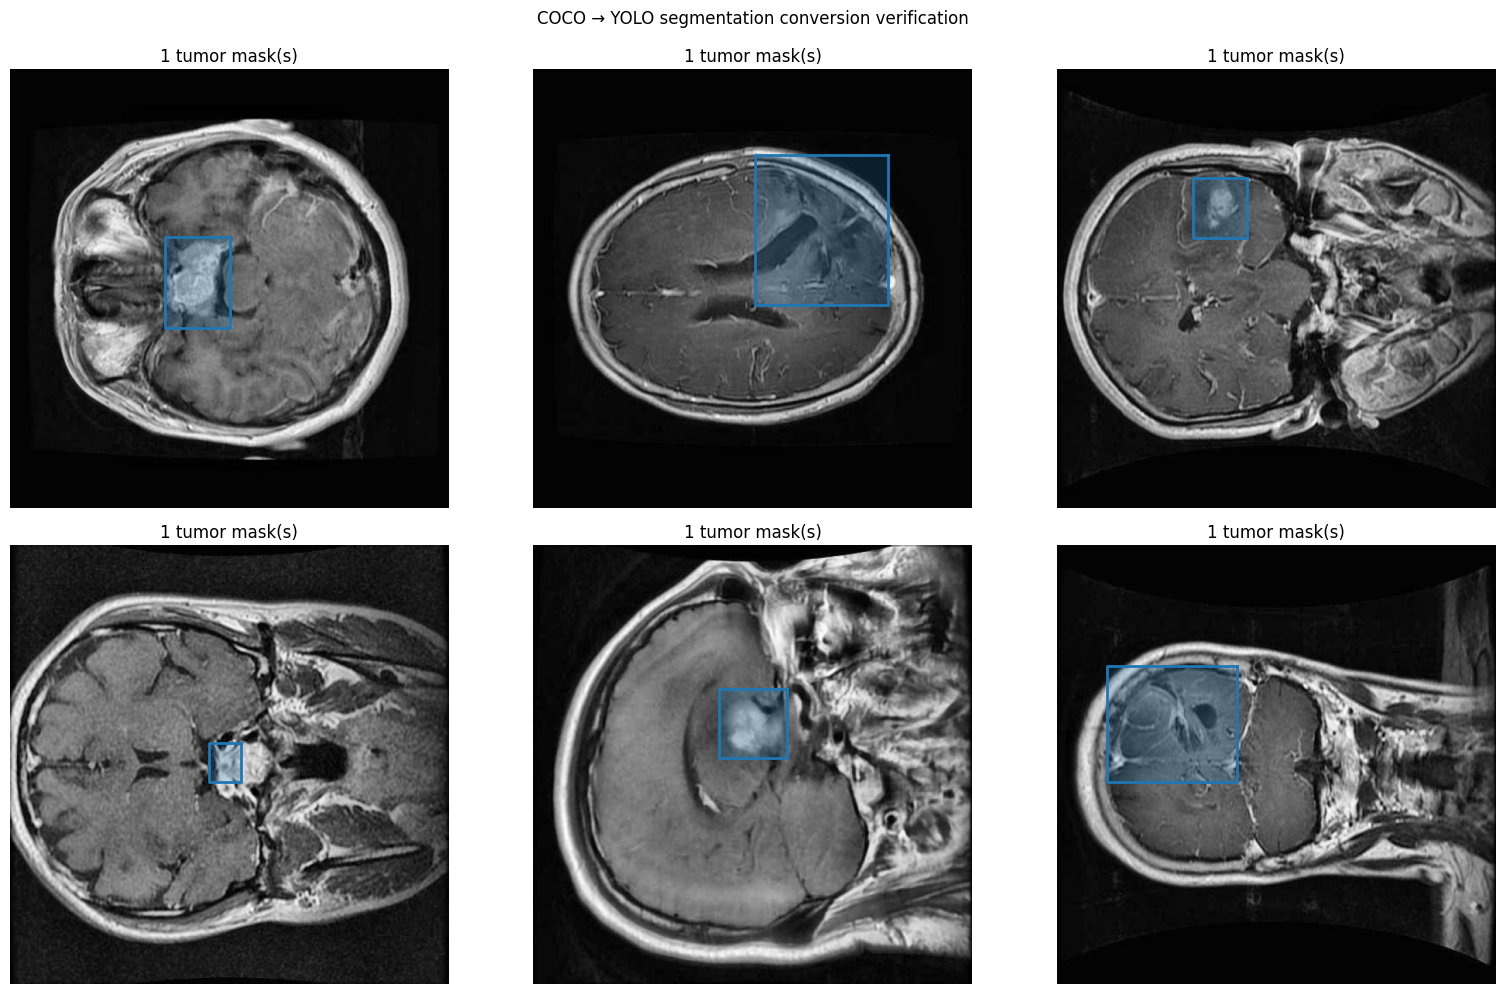

In [5]:
# Cell 5 — Visual verification of converted segmentation polygons
def read_yolo_segmentation_labels(label_path, image_width, image_height):
    instances = []
    for line in Path(label_path).read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        class_id = int(parts[0])
        coordinates = np.asarray(parts[1:], dtype=np.float64).reshape(-1, 2)
        coordinates[:, 0] *= image_width
        coordinates[:, 1] *= image_height
        instances.append((class_id, coordinates))
    return instances


train_rows = manifest[manifest["split"] == "train"]
sample_rows = train_rows.sample(
    min(6, len(train_rows)),
    random_state=cfg.seed,
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = np.asarray(axes).reshape(-1)

for axis, (_, row) in zip(axes, sample_rows.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    instances = read_yolo_segmentation_labels(
        row["label_path"],
        *image.size,
    )

    axis.imshow(image)
    for class_id, polygon in instances:
        closed_polygon = np.vstack([polygon, polygon[0]])
        axis.plot(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            linewidth=2,
            label=class_names[class_id],
        )
        axis.fill(
            polygon[:, 0],
            polygon[:, 1],
            alpha=0.22,
        )

    axis.set_title(f"{len(instances)} tumor mask(s)")
    axis.axis("off")

for axis in axes[len(sample_rows):]:
    axis.axis("off")

plt.suptitle("COCO → YOLO segmentation conversion verification", y=0.99)
plt.tight_layout()
plt.show()

## 2. Stage A — DINOv2 feature distillation

The distillation DataLoader reads only MRI images. Polygon annotations are not returned to the model during this stage.

The default teacher is **DINOv2 ViT-S/14**, which produces one patch feature for each $14\times14$ input region. With a $224\times224$ input, the teacher grid is:

$$
H_t=W_t=224/14=16,
$$

so the dense teacher map contains $16\times16=256$ patch tokens, each with 384 channels.

The same augmented image is sent to both networks. This is feature distillation, not two-view contrastive learning: DINOv2 provides the target representation and YOLOv26 learns to reproduce it.

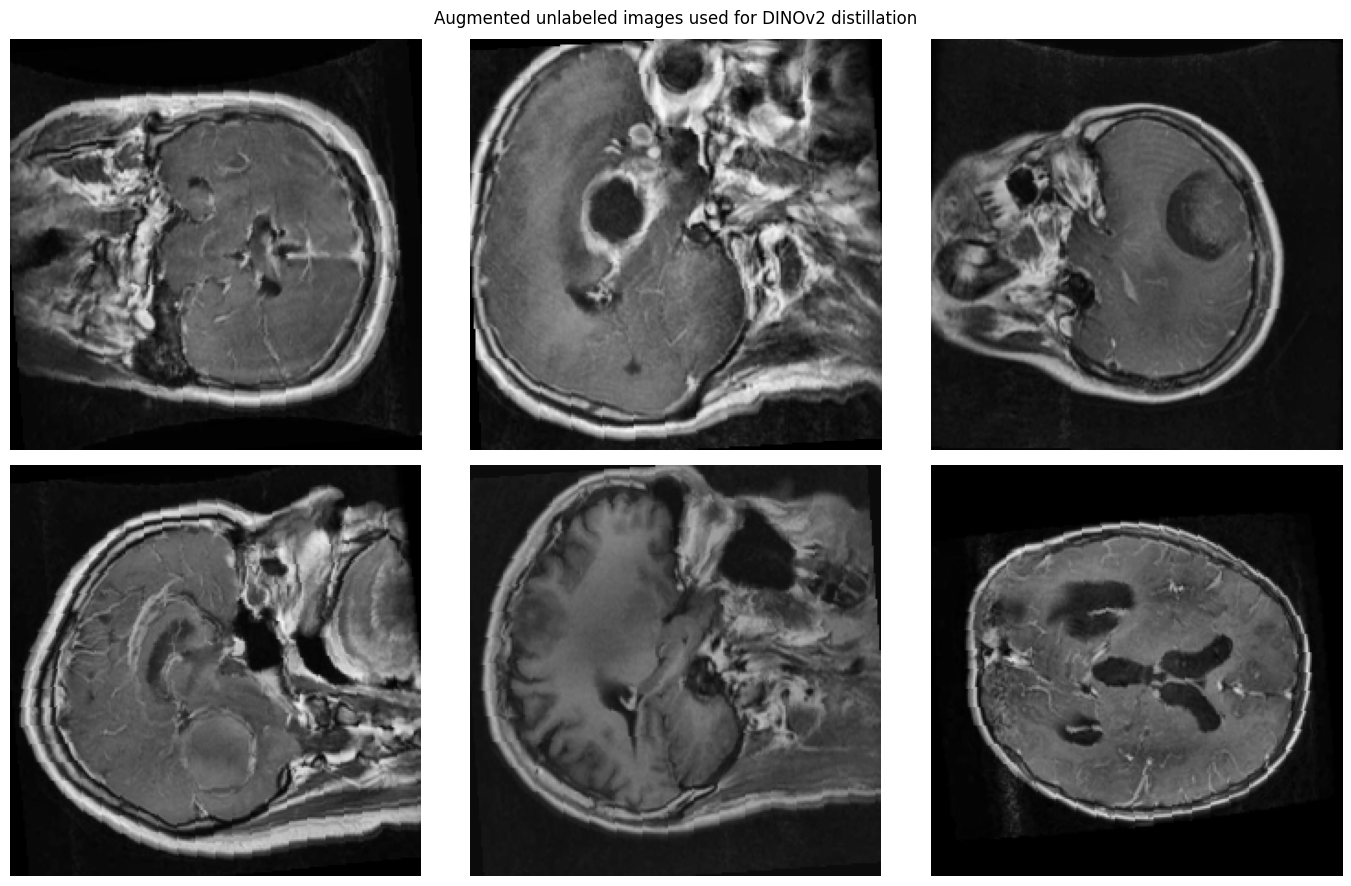

Distillation training images: 1502
Distillation validation images: 429


In [6]:
# Cell 6 — Distillation dataset, augmentation, and DataLoaders
NORMALISATION_MEAN = (0.485, 0.456, 0.406)
NORMALISATION_STD = (0.229, 0.224, 0.225)

# The same transformed image is used by teacher and student. Augmentations are
# deliberately moderate because the source images are medical scans.
distillation_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        cfg.distillation_image_size,
        scale=(0.75, 1.00),
        ratio=(0.90, 1.10),
        antialias=True,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.18,
            contrast=0.18,
            saturation=0.08,
            hue=0.01,
        )
    ], p=0.40),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize(
        (cfg.distillation_image_size, cfg.distillation_image_size),
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])


def denormalise(tensor):
    mean = torch.tensor(
        NORMALISATION_MEAN,
        dtype=tensor.dtype,
        device=tensor.device,
    ).view(3, 1, 1)
    std = torch.tensor(
        NORMALISATION_STD,
        dtype=tensor.dtype,
        device=tensor.device,
    ).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


class DistillationImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(image)


class RepresentationDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.loc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        return evaluation_transform(image), int(row["number_of_masks"])


train_image_paths = manifest.loc[
    manifest["split"] == "train", "image_path"
].tolist()
valid_image_paths = manifest.loc[
    manifest["split"] == "val", "image_path"
].tolist()

train_distillation_dataset = DistillationImageDataset(
    train_image_paths,
    distillation_transform,
)
valid_distillation_dataset = DistillationImageDataset(
    valid_image_paths,
    evaluation_transform,
)

loader_kwargs = {
    "num_workers": cfg.num_workers,
    "pin_memory": AMP_ENABLED,
}
if cfg.num_workers > 0:
    loader_kwargs["persistent_workers"] = cfg.persistent_workers
    loader_kwargs["prefetch_factor"] = cfg.prefetch_factor

train_distillation_loader = DataLoader(
    train_distillation_dataset,
    batch_size=cfg.distillation_batch_size,
    shuffle=True,
    drop_last=False,
    **loader_kwargs,
)
valid_distillation_loader = DataLoader(
    valid_distillation_dataset,
    batch_size=cfg.distillation_batch_size,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

preview_count = min(6, len(train_distillation_dataset))
preview_images = torch.stack([
    train_distillation_dataset[index]
    for index in range(preview_count)
])

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = np.asarray(axes).reshape(-1)
for axis, image_tensor in zip(axes, preview_images):
    axis.imshow(denormalise(image_tensor).permute(1, 2, 0))
    axis.axis("off")
for axis in axes[len(preview_images):]:
    axis.axis("off")
plt.suptitle("Augmented unlabeled images used for DINOv2 distillation")
plt.tight_layout()
plt.show()

print("Distillation training images:", len(train_distillation_dataset))
print("Distillation validation images:", len(valid_distillation_dataset))

In [7]:
# Cell 7 — YOLOv26 graph-aware multi-scale feature extractor
yolo = YOLO(cfg.yolo_model)
segmentation_network = yolo.model.to(device)


class UltralyticsFeatureExtractor(nn.Module):
    """Run the Ultralytics graph up to the feature maps consumed by the head."""

    def __init__(self, segmentation_model):
        super().__init__()
        self.segmentation_model = segmentation_model
        self.layers = segmentation_model.model
        self.head_layer = self.layers[-1]
        self.feature_layers = self.layers[:-1]
        self.save = set(getattr(segmentation_model, "save", []))

    @staticmethod
    def route(layer, current, saved):
        source = layer.f
        if source == -1:
            return current
        if isinstance(source, int):
            return saved[source]
        return [
            current if index == -1 else saved[index]
            for index in source
        ]

    def forward(self, images):
        saved = []
        current = images

        for layer in self.feature_layers:
            current = layer(self.route(layer, current, saved))
            saved.append(current if layer.i in self.save else None)

        sources = self.head_layer.f
        if isinstance(sources, int):
            features = [current if sources == -1 else saved[sources]]
        else:
            features = [
                current if index == -1 else saved[index]
                for index in sources
            ]

        if any(feature is None for feature in features):
            raise RuntimeError(
                "Could not recover all feature maps consumed by the segmentation head."
            )
        return features


student_extractor = UltralyticsFeatureExtractor(
    segmentation_network
).to(device)

with torch.inference_mode():
    dummy = torch.zeros(
        2,
        3,
        cfg.distillation_image_size,
        cfg.distillation_image_size,
        device=device,
    )
    with amp_context():
        dummy_student_features = student_extractor(dummy)

student_feature_shapes = [tuple(feature.shape) for feature in dummy_student_features]
student_feature_channels = [int(feature.shape[1]) for feature in dummy_student_features]

print("YOLOv26 student feature shapes:", student_feature_shapes)
print("YOLOv26 student feature channels:", student_feature_channels)

YOLOv26 student feature shapes: [(2, 64, 28, 28), (2, 128, 14, 14), (2, 256, 7, 7)]
YOLOv26 student feature channels: [64, 128, 256]


In [8]:
# Cell 8 — Load the frozen DINOv2 teacher and expose dense patch features
def clean_checkpoint_state_dict(state_dict):
    cleaned = {}
    prefixes = (
        "module.",
        "model.",
        "backbone.",
        "teacher.backbone.",
        "student.backbone.",
    )
    for key, value in state_dict.items():
        new_key = key
        changed = True
        while changed:
            changed = False
            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True
        cleaned[new_key] = value
    return cleaned


def load_local_weights(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    state_dict = checkpoint
    if isinstance(checkpoint, dict):
        for candidate in ("teacher", "model", "state_dict", "backbone"):
            if candidate in checkpoint and isinstance(checkpoint[candidate], dict):
                state_dict = checkpoint[candidate]
                break

    state_dict = clean_checkpoint_state_dict(state_dict)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Local DINOv2 weights loaded: {checkpoint_path}")
    print(f"Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}")


def load_dinov2_backbone():
    local_repo = Path(cfg.dinov2_local_repo) if cfg.dinov2_local_repo else None
    local_weights = Path(cfg.dinov2_local_weights) if cfg.dinov2_local_weights else None

    if local_repo is not None and local_repo.exists():
        backbone = torch.hub.load(
            str(local_repo),
            cfg.dinov2_model,
            source="local",
            pretrained=not (local_weights is not None and local_weights.exists()),
        )
        source = f"local repository: {local_repo}"
        if local_weights is not None and local_weights.exists():
            load_local_weights(backbone, local_weights)
        return backbone, source

    try:
        backbone = torch.hub.load(
            "facebookresearch/dinov2",
            cfg.dinov2_model,
            pretrained=True,
            trust_repo=True,
        )
        return backbone, "Meta DINOv2 PyTorch Hub"
    except Exception as hub_error:
        # Official torch.hub is preferred. timm is retained as a practical
        # fallback when GitHub Hub access is blocked but pretrained model
        # downloads are still available.
        print("Official torch.hub loading failed:", hub_error)
        try:
            import timm

            timm_name_map = {
                "dinov2_vits14": "vit_small_patch14_dinov2.lvd142m",
                "dinov2_vitb14": "vit_base_patch14_dinov2.lvd142m",
                "dinov2_vitl14": "vit_large_patch14_dinov2.lvd142m",
            }
            timm_name = timm_name_map[cfg.dinov2_model]
            backbone = timm.create_model(
                timm_name,
                pretrained=True,
                num_classes=0,
            )
            return backbone, f"timm fallback: {timm_name}"
        except Exception as timm_error:
            raise RuntimeError(
                "DINOv2 could not be loaded. Enable Kaggle Internet, or set "
                "CFG.dinov2_local_repo and CFG.dinov2_local_weights.\n"
                f"torch.hub error: {hub_error}\n"
                f"timm fallback error: {timm_error}"
            ) from timm_error


class DINOv2DenseTeacher(nn.Module):
    """Adapter that returns dense patch maps and a pooled global feature."""

    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

        patch_size = getattr(getattr(backbone, "patch_embed", None), "patch_size", 14)
        if isinstance(patch_size, (tuple, list)):
            patch_size = patch_size[0]
        self.patch_size = int(patch_size)

        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        self.backbone.eval()

    def train(self, mode=True):
        # Keep the teacher deterministic even when the parent distiller enters
        # training mode.
        super().train(False)
        self.backbone.eval()
        return self

    def forward(self, images):
        outputs = self.backbone.forward_features(images)

        patch_tokens = None
        global_token = None

        if isinstance(outputs, dict):
            patch_tokens = outputs.get("x_norm_patchtokens")
            global_token = outputs.get("x_norm_clstoken")
            if patch_tokens is None:
                for value in outputs.values():
                    if torch.is_tensor(value) and value.ndim == 3:
                        patch_tokens = value[:, 1:]
                        global_token = value[:, 0]
                        break
        elif torch.is_tensor(outputs):
            if outputs.ndim == 3:
                # Standard ViT output: CLS token followed by patch tokens.
                expected_patches = (
                    images.shape[-2] // self.patch_size
                ) * (
                    images.shape[-1] // self.patch_size
                )
                if outputs.shape[1] == expected_patches + 1:
                    global_token = outputs[:, 0]
                    patch_tokens = outputs[:, 1:]
                elif outputs.shape[1] == expected_patches:
                    patch_tokens = outputs
                    global_token = patch_tokens.mean(dim=1)
            elif outputs.ndim == 4:
                # Some model wrappers return BCHW or BHWC feature maps.
                if outputs.shape[1] < outputs.shape[-1]:
                    dense_map = outputs.permute(0, 3, 1, 2).contiguous()
                else:
                    dense_map = outputs
                return dense_map, dense_map.mean(dim=(2, 3))

        if patch_tokens is None:
            raise RuntimeError(
                "The DINOv2 teacher did not return recognizable patch tokens."
            )

        grid_h = images.shape[-2] // self.patch_size
        grid_w = images.shape[-1] // self.patch_size
        number_of_tokens = patch_tokens.shape[1]

        if grid_h * grid_w != number_of_tokens:
            side = int(round(math.sqrt(number_of_tokens)))
            if side * side != number_of_tokens:
                raise RuntimeError(
                    f"Cannot reshape {number_of_tokens} teacher tokens into a spatial grid."
                )
            grid_h = grid_w = side

        dense_map = patch_tokens.transpose(1, 2).reshape(
            patch_tokens.shape[0],
            patch_tokens.shape[2],
            grid_h,
            grid_w,
        )
        if global_token is None:
            global_token = dense_map.mean(dim=(2, 3))

        return dense_map, global_token


dinov2_backbone, teacher_source = load_dinov2_backbone()
teacher = DINOv2DenseTeacher(dinov2_backbone).to(device)
teacher.eval()

with torch.inference_mode():
    teacher_dummy = torch.zeros(
        2,
        3,
        cfg.distillation_image_size,
        cfg.distillation_image_size,
        device=device,
    )
    with amp_context():
        dummy_teacher_map, dummy_teacher_global = teacher(teacher_dummy)

teacher_dimension = int(dummy_teacher_map.shape[1])
print("Teacher source:", teacher_source)
print("DINOv2 patch size:", teacher.patch_size)
print("DINOv2 dense map:", tuple(dummy_teacher_map.shape))
print("DINOv2 global feature:", tuple(dummy_teacher_global.shape))
print("Teacher embedding dimension:", teacher_dimension)

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 395MB/s]


Teacher source: Meta DINOv2 PyTorch Hub
DINOv2 patch size: 14
DINOv2 dense map: (2, 384, 16, 16)
DINOv2 global feature: (2, 384)
Teacher embedding dimension: 384


In [9]:
# Cell 9 — Multi-scale student projector and DINOv2 distillation objectives
def group_count(channels):
    for groups in (32, 16, 8, 4, 2, 1):
        if channels % groups == 0:
            return groups
    return 1


class MultiScaleDINOProjector(nn.Module):
    def __init__(self, feature_channels, output_dim):
        super().__init__()
        hidden_dim = min(256, output_dim)

        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, hidden_dim, kernel_size=1, bias=False),
                nn.GroupNorm(group_count(hidden_dim), hidden_dim),
                nn.SiLU(inplace=True),
                nn.Conv2d(hidden_dim, output_dim, kernel_size=1, bias=True),
            )
            for channels in feature_channels
        ])

        # Learn how strongly each YOLO pyramid level contributes.
        self.level_logits = nn.Parameter(torch.zeros(len(feature_channels)))
        self.refine = nn.Sequential(
            nn.Conv2d(output_dim, output_dim, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(group_count(output_dim), output_dim),
            nn.SiLU(inplace=True),
            nn.Conv2d(output_dim, output_dim, kernel_size=1),
        )

    def forward(self, feature_maps, target_size):
        weights = self.level_logits.softmax(dim=0)
        projected_maps = []

        for projection, feature_map in zip(self.projections, feature_maps):
            value = projection(feature_map)
            if value.shape[-2:] != target_size:
                value = F.interpolate(
                    value,
                    size=target_size,
                    mode="bilinear",
                    align_corners=False,
                )
            projected_maps.append(value)

        fused = sum(
            weight * value
            for weight, value in zip(weights, projected_maps)
        )
        return self.refine(fused), weights


class DINOv2YOLODistiller(nn.Module):
    def __init__(self, teacher, student, student_channels, teacher_dim):
        super().__init__()
        self.teacher = teacher
        self.student = student
        self.projector = MultiScaleDINOProjector(
            feature_channels=student_channels,
            output_dim=teacher_dim,
        )

    def train(self, mode=True):
        super().train(mode)
        self.teacher.eval()
        return self

    def forward(self, images):
        with torch.no_grad():
            teacher_map, teacher_global = self.teacher(images)

        student_feature_maps = self.student(images)
        student_map, level_weights = self.projector(
            student_feature_maps,
            target_size=teacher_map.shape[-2:],
        )
        student_global = student_map.mean(dim=(2, 3))

        return {
            "teacher_map": teacher_map.detach(),
            "teacher_global": teacher_global.detach(),
            "student_map": student_map,
            "student_global": student_global,
            "level_weights": level_weights,
        }


def standardize_tokens(feature_map):
    tokens = feature_map.permute(0, 2, 3, 1).float()
    return F.layer_norm(tokens, (tokens.shape[-1],))


def compute_distillation_loss(outputs):
    teacher_tokens = standardize_tokens(outputs["teacher_map"])
    student_tokens = standardize_tokens(outputs["student_map"])

    teacher_unit = F.normalize(teacher_tokens, dim=-1, eps=1e-6)
    student_unit = F.normalize(student_tokens, dim=-1, eps=1e-6)

    dense_cosine = 1.0 - (
        teacher_unit * student_unit
    ).sum(dim=-1).mean()

    dense_huber = F.smooth_l1_loss(
        student_tokens,
        teacher_tokens,
    )

    teacher_global = F.normalize(
        outputs["teacher_global"].float(),
        dim=1,
        eps=1e-6,
    )
    student_global = F.normalize(
        outputs["student_global"].float(),
        dim=1,
        eps=1e-6,
    )
    global_cosine = 1.0 - (
        teacher_global * student_global
    ).sum(dim=1).mean()

    # Preserve spatial relationships among patch tokens.
    batch_size, grid_h, grid_w, channels = teacher_unit.shape
    teacher_flat = teacher_unit.reshape(batch_size, grid_h * grid_w, channels)
    student_flat = student_unit.reshape(batch_size, grid_h * grid_w, channels)
    teacher_affinity = torch.bmm(teacher_flat, teacher_flat.transpose(1, 2))
    student_affinity = torch.bmm(student_flat, student_flat.transpose(1, 2))
    affinity_loss = F.smooth_l1_loss(student_affinity, teacher_affinity)

    total = (
        cfg.dense_cosine_weight * dense_cosine
        + cfg.dense_huber_weight * dense_huber
        + cfg.global_cosine_weight * global_cosine
        + cfg.affinity_weight * affinity_loss
    )

    metrics = {
        "loss": total,
        "dense_cosine": dense_cosine,
        "dense_huber": dense_huber,
        "global_cosine": global_cosine,
        "affinity": affinity_loss,
        "mean_similarity": 1.0 - dense_cosine,
    }
    return total, metrics


distiller = DINOv2YOLODistiller(
    teacher=teacher,
    student=student_extractor,
    student_channels=student_feature_channels,
    teacher_dim=teacher_dimension,
).to(device)

# Store the random student state for before/after representation analysis.
initial_student_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in distiller.student.state_dict().items()
})

if cfg.use_torch_compile and hasattr(torch, "compile"):
    try:
        distiller = torch.compile(distiller, mode="reduce-overhead")
        print("torch.compile enabled.")
    except Exception as compile_error:
        print("torch.compile could not be enabled:", compile_error)

trainable_parameters = [
    parameter
    for parameter in distiller.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=cfg.distillation_learning_rate,
    weight_decay=cfg.distillation_weight_decay,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, cfg.distillation_epochs),
)

teacher_parameter_count = sum(
    parameter.numel()
    for parameter in unwrap_model(distiller).teacher.parameters()
)
student_parameter_count = sum(
    parameter.numel()
    for parameter in unwrap_model(distiller).student.parameters()
)
trainable_parameter_count = sum(
    parameter.numel()
    for parameter in trainable_parameters
)

print(f"Frozen teacher parameters: {teacher_parameter_count:,}")
print(f"YOLOv26 student parameters: {student_parameter_count:,}")
print(f"Total trainable parameters: {trainable_parameter_count:,}")

Frozen teacher parameters: 22,056,576
YOLOv26 student parameters: 3,126,280
Total trainable parameters: 5,014,283


In [10]:
# Cell 10 — DINOv2 distillation training and validation with progress bars
def move_to_device(images):
    return images.to(device, non_blocking=AMP_ENABLED).contiguous()


def run_distillation_epoch(
    model,
    loader,
    optimizer=None,
    scaler=None,
    description="Distillation",
):
    training = optimizer is not None
    model.train(training)

    metric_sums = {
        "loss": 0.0,
        "dense_cosine": 0.0,
        "dense_huber": 0.0,
        "global_cosine": 0.0,
        "affinity": 0.0,
        "mean_similarity": 0.0,
    }
    processed_batches = 0
    processed_images = 0
    start_time = time.perf_counter()

    progress = tqdm(
        loader,
        desc=description,
        dynamic_ncols=True,
        leave=False,
        unit="batch",
    )

    if training:
        optimizer.zero_grad(set_to_none=True)

    for batch_index, images in enumerate(progress, start=1):
        images = move_to_device(images)

        with torch.set_grad_enabled(training):
            with amp_context():
                outputs = model(images)
                loss, metrics = compute_distillation_loss(outputs)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite DINOv2 distillation loss detected.")

            scaled_loss = loss / cfg.gradient_accumulation_steps

            if training:
                if AMP_ENABLED:
                    scaler.scale(scaled_loss).backward()
                else:
                    scaled_loss.backward()

                should_step = (
                    batch_index % cfg.gradient_accumulation_steps == 0
                    or batch_index == len(loader)
                )
                if should_step:
                    if AMP_ENABLED:
                        scaler.unscale_(optimizer)

                    torch.nn.utils.clip_grad_norm_(
                        trainable_parameters,
                        max_norm=5.0,
                    )

                    if AMP_ENABLED:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()

                    optimizer.zero_grad(set_to_none=True)

        for name in metric_sums:
            metric_sums[name] += float(metrics[name].detach().item())

        processed_batches += 1
        processed_images += images.size(0)
        elapsed = max(time.perf_counter() - start_time, 1e-9)

        progress.set_postfix(
            loss=f"{metric_sums['loss'] / processed_batches:.4f}",
            sim=f"{metric_sums['mean_similarity'] / processed_batches:.3f}",
            global_cos=f"{metric_sums['global_cosine'] / processed_batches:.3f}",
            img_s=f"{processed_images / elapsed:.1f}",
            lr=(
                f"{optimizer.param_groups[0]['lr']:.2e}"
                if training
                else "validation"
            ),
        )

    if processed_batches == 0:
        raise ValueError("No distillation batches were processed.")

    elapsed = time.perf_counter() - start_time
    results = {
        name: value / processed_batches
        for name, value in metric_sums.items()
    }
    results.update({
        "processed_images": processed_images,
        "elapsed_seconds": elapsed,
        "images_per_second": processed_images / max(elapsed, 1e-9),
    })
    return results


# Smoke test catches teacher-token and YOLO feature-shape incompatibilities
# before the full two-epoch run.
smoke_images = next(iter(train_distillation_loader))
smoke_images = move_to_device(smoke_images[: min(2, len(smoke_images))])

distiller.train()
with torch.no_grad():
    with amp_context():
        smoke_outputs = distiller(smoke_images)
        smoke_loss, smoke_metrics = compute_distillation_loss(smoke_outputs)

assert smoke_outputs["student_map"].shape == smoke_outputs["teacher_map"].shape
assert torch.isfinite(smoke_loss)
print(
    "Smoke test passed | "
    f"teacher={tuple(smoke_outputs['teacher_map'].shape)} | "
    f"student={tuple(smoke_outputs['student_map'].shape)} | "
    f"loss={smoke_loss.item():.4f}"
)

history_records = []
best_validation_loss = float("inf")
best_distiller_state = None
total_training_start = time.perf_counter()

epoch_progress = tqdm(
    range(1, cfg.distillation_epochs + 1),
    desc="Overall DINOv2 → YOLOv26 progress",
    dynamic_ncols=True,
    unit="epoch",
)

for epoch in epoch_progress:
    train_result = run_distillation_epoch(
        distiller,
        train_distillation_loader,
        optimizer=optimizer,
        scaler=SCALER,
        description=f"Distill train {epoch}/{cfg.distillation_epochs}",
    )

    with torch.inference_mode():
        valid_result = run_distillation_epoch(
            distiller,
            valid_distillation_loader,
            optimizer=None,
            description=f"Distill valid {epoch}/{cfg.distillation_epochs}",
        )

    scheduler.step()

    record = {
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "valid_loss": valid_result["loss"],
        "train_dense_cosine": train_result["dense_cosine"],
        "valid_dense_cosine": valid_result["dense_cosine"],
        "train_dense_huber": train_result["dense_huber"],
        "valid_dense_huber": valid_result["dense_huber"],
        "train_global_cosine": train_result["global_cosine"],
        "valid_global_cosine": valid_result["global_cosine"],
        "train_affinity": train_result["affinity"],
        "valid_affinity": valid_result["affinity"],
        "train_mean_similarity": train_result["mean_similarity"],
        "valid_mean_similarity": valid_result["mean_similarity"],
        "train_images_per_second": train_result["images_per_second"],
        "valid_images_per_second": valid_result["images_per_second"],
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    history_records.append(record)

    if valid_result["loss"] < best_validation_loss:
        best_validation_loss = valid_result["loss"]
        best_distiller_state = copy.deepcopy({
            key: value.detach().cpu()
            for key, value in distiller.state_dict().items()
        })

    epoch_progress.set_postfix(
        train=f"{train_result['loss']:.4f}",
        valid=f"{valid_result['loss']:.4f}",
        similarity=f"{valid_result['mean_similarity']:.3f}",
        best=f"{best_validation_loss:.4f}",
    )


total_training_seconds = time.perf_counter() - total_training_start

if best_distiller_state is None:
    raise RuntimeError("No valid DINOv2 distillation checkpoint was produced.")

distiller.load_state_dict(best_distiller_state)
distiller.to(device)

distillation_history = pd.DataFrame(history_records)
distillation_history.to_csv(
    DISTILL_OUTPUT_DIR / "dinov2_distillation_history.csv",
    index=False,
)

core_distiller = unwrap_model(distiller)
torch.save(
    {
        "config": asdict(cfg),
        "class_names": class_names,
        "teacher_source": teacher_source,
        "teacher_model": cfg.dinov2_model,
        "student_state_dict": core_distiller.student.state_dict(),
        "projector_state_dict": core_distiller.projector.state_dict(),
        "best_validation_loss": best_validation_loss,
        "total_training_seconds": total_training_seconds,
    },
    DISTILL_OUTPUT_DIR / "dinov2_yolov26_distillation_checkpoint.pt",
)

display(distillation_history.round(4))
print(f"Best validation distillation loss: {best_validation_loss:.4f}")
print(f"Total distillation time: {total_training_seconds / 60:.2f} minutes")

Smoke test passed | teacher=(2, 384, 16, 16) | student=(2, 384, 16, 16) | loss=1.7273


Overall DINOv2 → YOLOv26 progress:   0%|          | 0/5 [00:00<?, ?epoch/s]

Distill train 1/5:   0%|          | 0/188 [00:00<?, ?batch/s]

Distill valid 1/5:   0%|          | 0/54 [00:00<?, ?batch/s]

Distill train 2/5:   0%|          | 0/188 [00:00<?, ?batch/s]

...

Distill valid 4/5:   0%|          | 0/54 [00:00<?, ?batch/s]

Distill train 5/5:   0%|          | 0/188 [00:00<?, ?batch/s]

Distill valid 5/5:   0%|          | 0/54 [00:00<?, ?batch/s]

,epoch,train_loss,valid_loss,train_dense_cosine,valid_dense_cosine,train_dense_huber,valid_dense_huber,train_global_cosine,valid_global_cosine,train_affinity,valid_affinity,train_mean_similarity,valid_mean_similarity,train_images_per_second,valid_images_per_second,learning_rate
0,1,0.4953,0.4261,0.3205,0.2716,0.2837,0.2474,0.1970,0.1807,0.0537,0.0231,0.6795,0.7284,22.0320,133.5374,0.0002
1,2,0.3794,0.3836,0.2428,0.2466,0.2230,0.2270,0.1576,0.1560,0.0212,0.0224,0.7572,0.7534,93.1825,178.2928,0.0001
2,3,0.3464,0.3485,0.2253,0.2274,0.2081,0.2103,0.1346,0.1339,0.0171,0.0157,0.7747,0.7726,91.4827,174.6383,0.0001
3,4,0.3264,0.3353,0.2146,0.2210,0.1987,0.2045,0.1211,0.1232,0.0156,0.0162,0.7854,0.7790,94.2188,179.2156,0.0000
4,5,0.3162,0.3268,0.2087,0.2154,0.1935,0.1999,0.1153,0.1196,0.0150,0.0155,0.7913,0.7846,91.9763,176.6512,0.0000


Best validation distillation loss: 0.3268
Total distillation time: 2.46 minutes


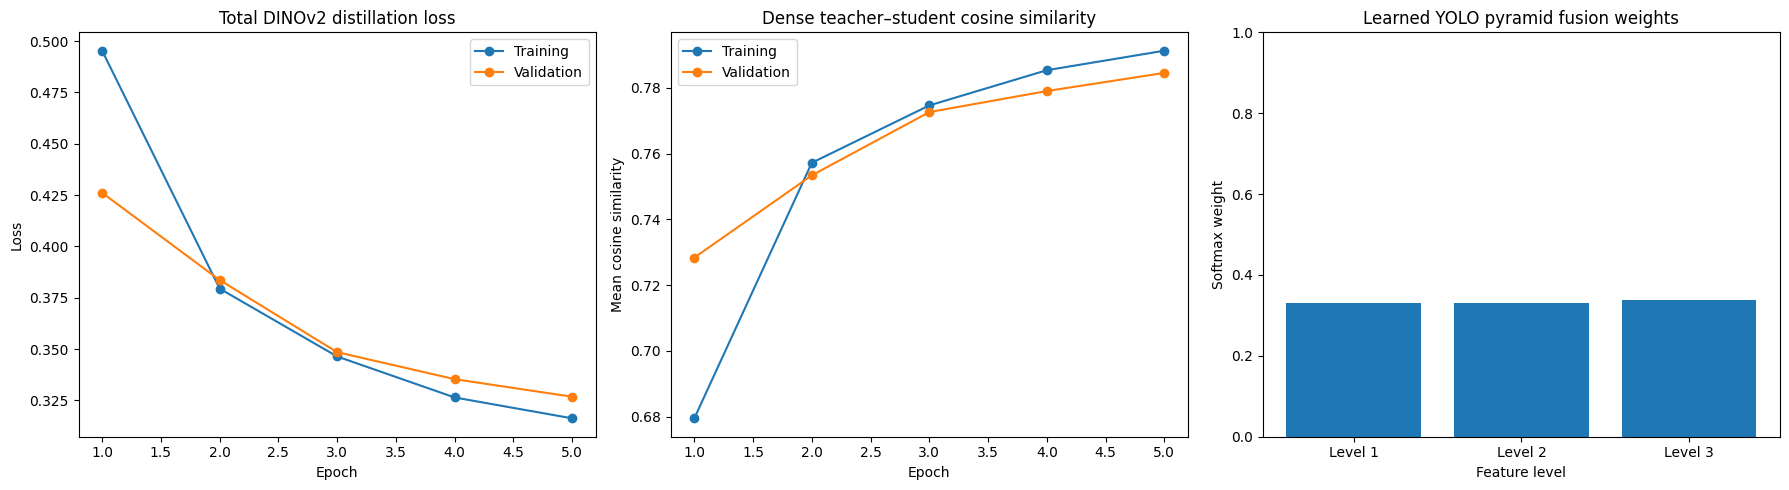

In [11]:
# Cell 11 — Distillation curves and learned multi-scale fusion weights
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    distillation_history["epoch"],
    distillation_history["train_loss"],
    marker="o",
    label="Training",
)
axes[0].plot(
    distillation_history["epoch"],
    distillation_history["valid_loss"],
    marker="o",
    label="Validation",
)
axes[0].set_title("Total DINOv2 distillation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    distillation_history["epoch"],
    distillation_history["train_mean_similarity"],
    marker="o",
    label="Training",
)
axes[1].plot(
    distillation_history["epoch"],
    distillation_history["valid_mean_similarity"],
    marker="o",
    label="Validation",
)
axes[1].set_title("Dense teacher–student cosine similarity")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean cosine similarity")
axes[1].legend()

core_distiller = unwrap_model(distiller)
with torch.no_grad():
    fusion_weights = core_distiller.projector.level_logits.softmax(dim=0).cpu().numpy()

axes[2].bar(
    [f"Level {index + 1}" for index in range(len(fusion_weights))],
    fusion_weights,
)
axes[2].set_title("Learned YOLO pyramid fusion weights")
axes[2].set_xlabel("Feature level")
axes[2].set_ylabel("Softmax weight")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    DISTILL_OUTPUT_DIR / "dinov2_distillation_curves.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 3. Representation analysis before supervised fine-tuning

The following t-SNE diagnostic compares the randomly initialized YOLOv26 representation with the DINOv2-distilled representation. Each image is represented by concatenating globally pooled multi-scale YOLO feature maps. Color denotes the number of annotated tumor objects in the image.

This visualization is qualitative. It does not replace downstream mask mAP, precision, recall, or multi-seed experiments.

Extracting YOLO features:   0%|          | 0/27 [00:00<?, ?it/s]

Extracting YOLO features:   0%|          | 0/27 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f63e0118f40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f63e0118f40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

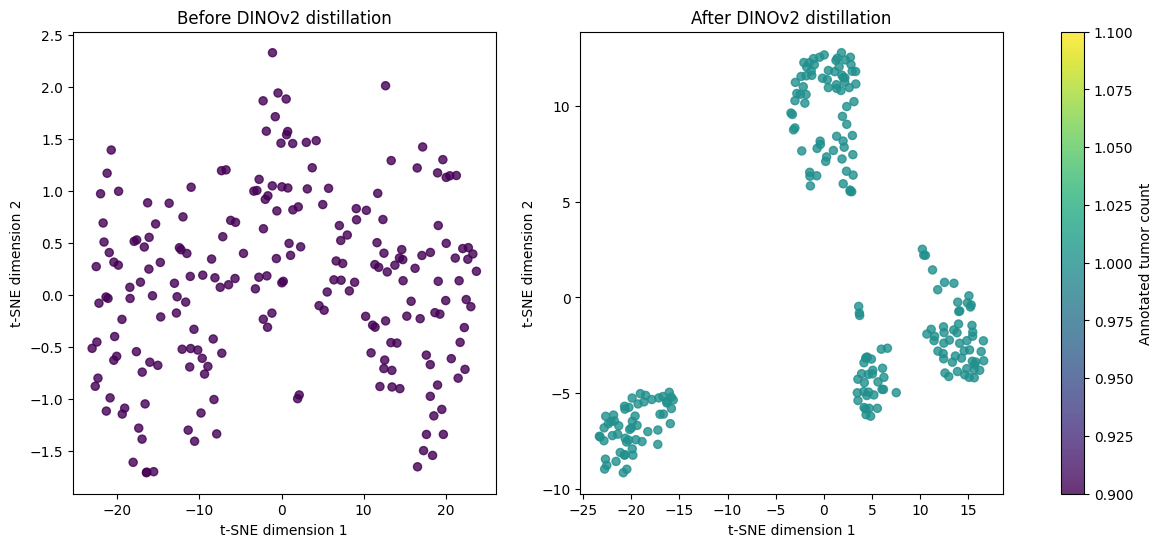

In [12]:
# Cell 12 — t-SNE before and after DINOv2 distillation
feature_frame = manifest[manifest["split"] == "test"].copy()
if len(feature_frame) > cfg.tsne_max_samples:
    feature_frame = feature_frame.sample(
        cfg.tsne_max_samples,
        random_state=cfg.seed,
    )

feature_loader = DataLoader(
    RepresentationDataset(feature_frame),
    batch_size=cfg.distillation_batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=AMP_ENABLED,
)


def collect_student_features(extractor):
    extractor.eval()
    feature_values = []
    mask_counts = []

    with torch.inference_mode():
        for images, counts in tqdm(
            feature_loader,
            desc="Extracting YOLO features",
            leave=False,
        ):
            images = move_to_device(images)
            with amp_context():
                maps = extractor(images)
                pooled = torch.cat([
                    F.adaptive_avg_pool2d(feature_map, 1).flatten(1)
                    for feature_map in maps
                ], dim=1)

            feature_values.append(pooled.float().cpu().numpy())
            mask_counts.append(counts.numpy())

    return np.concatenate(feature_values), np.concatenate(mask_counts)


core_distiller = unwrap_model(distiller)
trained_student_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in core_distiller.student.state_dict().items()
})

after_features, mask_counts = collect_student_features(core_distiller.student)

core_distiller.student.load_state_dict(initial_student_state)
core_distiller.student.to(device)
before_features, _ = collect_student_features(core_distiller.student)

# Restore the distilled student before checkpoint transfer.
core_distiller.student.load_state_dict(trained_student_state)
core_distiller.student.to(device)

sample_count = len(feature_frame)
if sample_count >= 3:
    perplexity = max(2, min(30, (sample_count - 1) // 3))

    before_embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=cfg.seed,
    ).fit_transform(before_features)

    after_embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=cfg.seed,
    ).fit_transform(after_features)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for axis, embedding, title in [
        (axes[0], before_embedding, "Before DINOv2 distillation"),
        (axes[1], after_embedding, "After DINOv2 distillation"),
    ]:
        scatter = axis.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=mask_counts,
            s=34,
            alpha=0.8,
        )
        axis.set_title(title)
        axis.set_xlabel("t-SNE dimension 1")
        axis.set_ylabel("t-SNE dimension 2")

    fig.colorbar(scatter, ax=axes, label="Annotated tumor count")
    plt.savefig(
        DISTILL_OUTPUT_DIR / "tsne_before_after_dinov2.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("t-SNE skipped because fewer than three test images are available.")

## 4. Stage B — YOLOv26 segmentation fine-tuning

The frozen DINOv2 teacher and feature projector are no longer required. The distilled segmentation network is extracted from:

```python
unwrap_model(distiller).student.segmentation_model
```

The notebook creates an independent CPU copy, saves an Ultralytics-compatible checkpoint, restores all parameters as trainable, and fine-tunes the complete segmentation model for exactly two epochs.

In [13]:
# Cell 13 — Save the DINOv2-distilled YOLOv26 segmenter and fine-tune
ssl_initialized_path = WORKING_ROOT / "yolov26_seg_dinov2_initialized.pt"

trained_distiller = unwrap_model(distiller)

# The student wrapper contains the complete YOLOv26 segmentation network.
# Its backbone and neck were updated by DINOv2 feature distillation.
ssl_segmentation_model = (
    trained_distiller
    .student
    .segmentation_model
)

# Build an independent CPU model for an Ultralytics-compatible checkpoint.
checkpoint_model = copy.deepcopy(
    ssl_segmentation_model
).float().cpu()

for parameter in checkpoint_model.parameters():
    parameter.requires_grad = True

checkpoint_model.eval()

checkpoint = {
    "model": checkpoint_model,
    "ema": None,
    "optimizer": None,
    "train_args": {},
    "epoch": -1,
    "best_fitness": None,
    "date": pd.Timestamp.utcnow().isoformat(),
    "version": ultralytics.__version__,
    "license": "AGPL-3.0",
}

torch.save(checkpoint, ssl_initialized_path)
print("DINOv2-distilled YOLOv26 checkpoint saved to:", ssl_initialized_path)

# Supervised tumor-segmentation fine-tuning: exactly two epochs.
segmenter = YOLO(str(ssl_initialized_path))
train_results = segmenter.train(
    data=str(data_yaml),
    epochs=cfg.segmentation_epochs,
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    patience=cfg.segmentation_patience,
    seed=cfg.seed,
    deterministic=True,
    pretrained=False,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="dinov2_yolov26_seg",
    exist_ok=True,
    plots=True,
    verbose=True,
)

best_segmenter_path = Path(segmenter.trainer.best)
print("Best segmenter:", best_segmenter_path)

DINOv2-distilled YOLOv26 checkpoint saved to: /kaggle/working/cse445_dinov2_yolov26/yolov26_seg_dinov2_initialized.pt
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cse445_dinov2_yolov26/brain_tumor_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train

In [14]:
# Cell 14 — Held-out tumor-segmentation evaluation
best_segmenter = YOLO(str(best_segmenter_path))

test_metrics = best_segmenter.val(
    data=str(data_yaml),
    split="test",
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    plots=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="dinov2_yolov26_seg_test",
    exist_ok=True,
)

metrics_frame = pd.DataFrame([
    {"metric": key, "value": float(value)}
    for key, value in test_metrics.results_dict.items()
])
metrics_frame.to_csv(
    WORKING_ROOT / "dinov2_yolov26_seg_test_metrics.csv",
    index=False,
)
display(metrics_frame)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1140.5±475.6 MB/s, size: 37.0 KB)
val: Scanning /kaggle/working/cse445_dinov2_yolov26/brain_tumor_yolo_seg/labels/test... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 1.1Kit/s 0.2s
val: New cache created: /kaggle/working/cse445_dinov2_yolov26/brain_tumor_yolo_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 5.7it/s 4.7s
                   all        215        215      0.424      0.528      0.496      0.247      0.419      0.526      0.488      0.243
                     0        118        118      0.377      0.231      0.276      0.117       0.38      0.237      0.275      0.118
                     1         97         

,metric,value
0,metrics/precision(B),0.423630
1,metrics/recall(B),0.527959
2,metrics/mAP50(B),0.496378
3,metrics/mAP50-95(B),0.246579
4,metrics/precision(M),0.419072
5,metrics/recall(M),0.525861
6,metrics/mAP50(M),0.488013
7,metrics/mAP50-95(M),0.242707
8,fitness,0.489286


Results saved to /kaggle/working/cse445_dinov2_yolov26/segmentation_runs/qualitative_segmentation_predictions


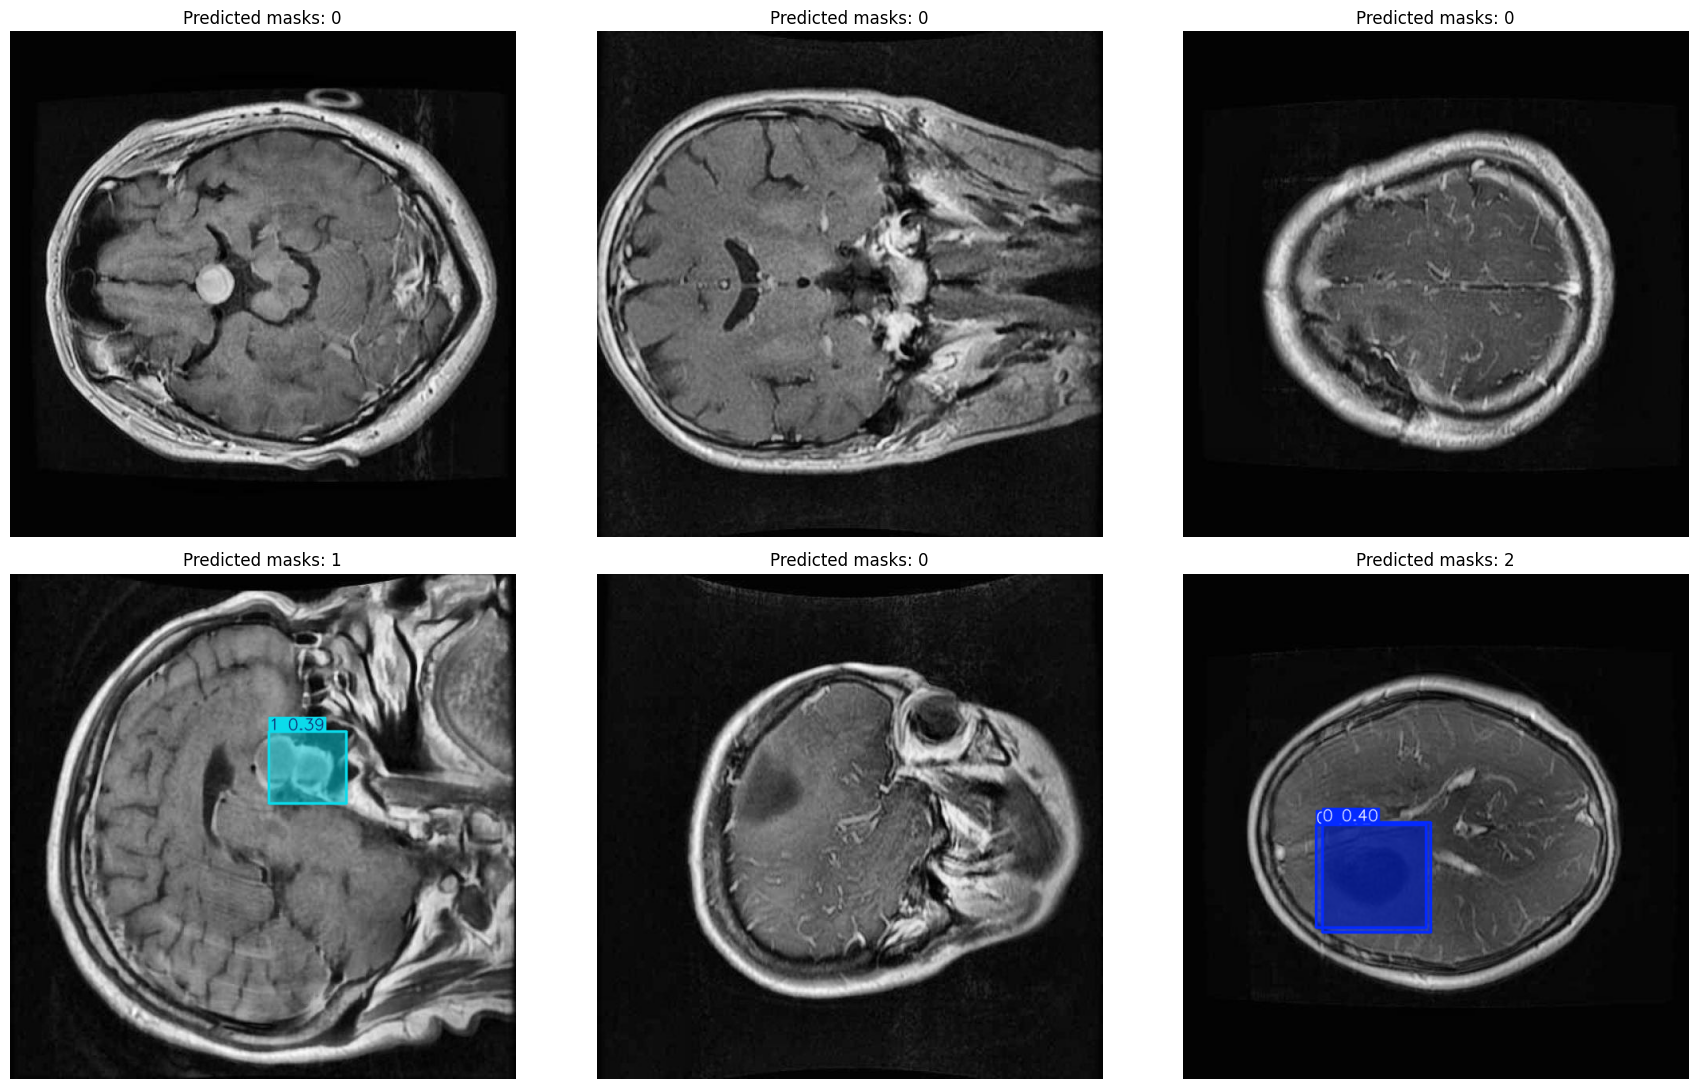

In [15]:
# Cell 15 — Qualitative tumor-mask predictions
number_of_test_images = int((manifest["split"] == "test").sum())
test_images = manifest.loc[
    manifest["split"] == "test",
    "image_path",
].sample(
    min(6, number_of_test_images),
    random_state=cfg.seed,
).tolist()

prediction_results = best_segmenter.predict(
    source=test_images,
    imgsz=cfg.segmentation_image_size,
    conf=0.25,
    iou=0.70,
    save=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="qualitative_segmentation_predictions",
    exist_ok=True,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = np.asarray(axes).reshape(-1)

for axis, result in zip(axes, prediction_results):
    axis.imshow(result.plot()[:, :, ::-1])
    predicted_masks = 0 if result.masks is None else len(result.masks.data)
    axis.set_title(f"Predicted masks: {predicted_masks}")
    axis.axis("off")

for axis in axes[len(prediction_results):]:
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    WORKING_ROOT / "qualitative_segmentation_predictions.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## Recommended comparative experiment

Use identical splits, image sizes, augmentations, fine-tuning epochs, and random seeds for all variants:

| Experiment | Initialization | Distillation/SSL epochs | Segmentation epochs |
|---|---|---:|---:|
| A | Random YOLOv26 | 0 | 2 |
| B | DINOv2-distilled YOLOv26 | 2 | 2 |
| C | MAE-trained YOLOv26 | 2 | 2 |
| D | BYOL-trained YOLOv26 | 2 | 2 |
| E | Supervised pretrained YOLOv26, when available | 0 | 2 |

Record box and mask precision, recall, mAP@0.5, mAP@0.5:0.95, training time, peak GPU memory, and inference latency. For a publishable result, increase the epoch counts substantially and repeat every experiment with at least three random seeds.

In [16]:
# Cell 16 — Output summary and downloadable archive
important_paths = [
    data_yaml,
    PREPARED_ROOT / "manifest.csv",
    DISTILL_OUTPUT_DIR / "dinov2_yolov26_distillation_checkpoint.pt",
    DISTILL_OUTPUT_DIR / "dinov2_distillation_history.csv",
    DISTILL_OUTPUT_DIR / "dinov2_distillation_curves.png",
    DISTILL_OUTPUT_DIR / "tsne_before_after_dinov2.png",
    WORKING_ROOT / "dinov2_yolov26_seg_test_metrics.csv",
    WORKING_ROOT / "qualitative_segmentation_predictions.png",
    ssl_initialized_path,
    best_segmenter_path,
]

print("Pipeline completed. Important artifacts:")
for path in important_paths:
    print(" -", path)

archive_path = shutil.make_archive(
    str(WORKING_ROOT),
    "zip",
    root_dir=WORKING_ROOT,
)
print("Downloadable output archive:", archive_path)

Pipeline completed. Important artifacts:
 - /kaggle/working/cse445_dinov2_yolov26/brain_tumor_yolo_seg/data.yaml
 - /kaggle/working/cse445_dinov2_yolov26/brain_tumor_yolo_seg/manifest.csv
 - /kaggle/working/cse445_dinov2_yolov26/dinov2_distillation_outputs/dinov2_yolov26_distillation_checkpoint.pt
 - /kaggle/working/cse445_dinov2_yolov26/dinov2_distillation_outputs/dinov2_distillation_history.csv
 - /kaggle/working/cse445_dinov2_yolov26/dinov2_distillation_outputs/dinov2_distillation_curves.png
 - /kaggle/working/cse445_dinov2_yolov26/dinov2_distillation_outputs/tsne_before_after_dinov2.png
 - /kaggle/working/cse445_dinov2_yolov26/dinov2_yolov26_seg_test_metrics.csv
 - /kaggle/working/cse445_dinov2_yolov26/qualitative_segmentation_predictions.png
 - /kaggle/working/cse445_dinov2_yolov26/yolov26_seg_dinov2_initialized.pt
 - /kaggle/working/cse445_dinov2_yolov26/segmentation_runs/dinov2_yolov26_seg/weights/best.pt
Downloadable output archive: /kaggle/working/cse445_dinov2_yolov26.zip


## Classroom interpretation guide

### What should happen during DINOv2 distillation?

- Total validation loss should generally decline.
- Dense teacher–student cosine similarity should generally increase.
- Learned fusion weights may show which YOLO pyramid level contributes most strongly to matching the DINOv2 patch grid.
- Two epochs may produce only a small change; this is expected for a demonstration run.

### Is this ordinary DINO training?

No. DINOv2 itself is already pretrained and remains frozen. This notebook performs **cross-architecture feature distillation** from a DINOv2 transformer teacher into a YOLOv26 convolutional student.

### What is transferred to segmentation?

Only the complete YOLOv26 segmentation network inside `distiller.student.segmentation_model`. The DINOv2 teacher and projection layers are discarded.

### Why use dense tokens rather than only the CLS token?

Tumor segmentation is a spatial task. Dense patch-token supervision carries information about anatomical layout and local structures, whereas a single image-level feature discards much of that spatial detail.

### Does lower distillation loss prove better segmentation?

No. It only shows better agreement with the teacher representation. The held-out tumor-segmentation metrics determine whether the transferred representation improves the downstream task.

### Why might DINOv2 be imperfect for MRI images?

The standard DINOv2 teacher was pretrained primarily on natural imagery. It can still provide strong generic visual features, but domain-specific medical pretraining or an X-ray/MRI-oriented teacher may transfer better.

## Optional ways to optimize the notebook

### Longer distillation and fine-tuning

```python
cfg.distillation_epochs = 25
cfg.segmentation_epochs = 50
```

### Larger DINOv2 teacher

```python
cfg.dinov2_model = "dinov2_vitb14"
cfg.distillation_batch_size = 4
```

### Offline Kaggle execution

Attach the official DINOv2 repository and weights as Kaggle datasets, then set:

```python
cfg.dinov2_local_repo = "/kaggle/input/dinov2-repository/dinov2"
cfg.dinov2_local_weights = "/kaggle/input/dinov2-weights/dinov2_vits14_pretrain.pth"
```

### Lower GPU memory

```python
cfg.distillation_batch_size = 4
cfg.gradient_accumulation_steps = 2
cfg.segmentation_batch_size = 4
```

### Stronger YOLOv26 student

```python
cfg.yolo_model = "yolo26s-seg.yaml"
```

### Ablation study

Test the contribution of each loss term by setting one weight to zero:

```python
cfg.affinity_weight = 0.0
cfg.global_cosine_weight = 0.0
```

### Research-quality evaluation

- use substantially longer pretraining and fine-tuning;
- compare DINOv2-S, DINOv2-B, and domain-specific medical teachers;
- repeat each experiment with at least three seeds;
- report confidence intervals and per-image failure cases;
- compare random, supervised, SimCLR, MoCo, BYOL, MAE, and DINOv2 initialization;
- measure GPU memory, throughput, and inference latency.

## References

- Meta AI Research, DINOv2 official repository: `https://github.com/facebookresearch/dinov2`
- Ultralytics segmentation documentation: `https://docs.ultralytics.com/tasks/segment/`